<a href="https://colab.research.google.com/github/fabianobarreto350-gif/MVP_Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(Fabiano_Humberto_Duarte_Barreto).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Fabiano Humberto Duarte Barreto

**Matrícula:** 4052025001285

**Dataset:** https://raw.githubusercontent.com/fabianobarreto350-gif/MVP_Analise_de_Dados_e_Boas_Praticas/refs/heads/main/Car%20Sales.xlsx%20-%20car_data.csv





# Descrição do Problema

O conjunto de dados Car Sales Report consiste em registros de venda de automóveis com informações sobre os clientes, características dos automóveis, data da venda, nome da empresa revendedora e as cidades onde as vendas ocorreram (todas nos Estados Unidos). Represento uma consultoria que foi contratada por uma empresa de revenda de carros para fazer uma análise preditiva sobre o faturamento dos próximos meses das cidades onde as lojas estão localizadas. Neste contexto, será analisado o comportamento das vendas presentes no dataset para preparar um modelo de predição de faturamento mensal por cidade. Para cada cidade serão levados em consideração as seguintes características: faturamento (somatório do valor das vendas), renda anual do cliente, comportamento das vendas ao longo dos meses.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Para cada cidade existe uma preferência do tipo de carroceria do automóvel?**

2. **Existe uma correlação entre renda anual do cliente e preço do automóvel?**

3. **Qual o faturamento médio por cidade?**

4. **Qual a marca mais vendida por cidade?**

5. **Qual cidade apresentou o maior crescimento percentual nos últimos 3 meses do período presente no dataset?**


## Tipo de Problema

Este é um problema supervisionado de regressão para prever o faturamento futuro por cidade, dado um conjunto de características como preço (Price ($)), loja (Dealer_Region), renda anual do cliente (Annual Income), data da venda (Date).

## Seleção de Dados

O dataset Car Sales Report foi obtido através do Kaggle: https://www.kaggle.com/datasets/missionjee/car-sales-report

## Atributos do Dataset

O dataset Car Sales Report contém 23906 registros de venda de automóveis. Possui dezesseis (16) atributos:

- ***Car_id*** (identificador único de cada venda)
- ***Date*** (data da venda do automóvel)
- ***Customer Name*** (nome do cliente)
- ***Gender*** (sexo do cliente)
- ***Annual_Income*** (renda anual do cliente em dólar USD)
- ***Dealer_Name*** (nome da empresa ou loja vendedora)
- ***Company*** (marca do automóvel)
- ***Model*** (modelo do automóvel)
- ***Engine*** (especificação do tipo de motor do automóvel)
- ***Transmission*** (tipo de transmissão do automóvel)
- ***Color*** (cor exterior do automóvel)
- ***Price*** (preço de venda do automóvel em dólar USD)
- ***Dealer_No*** (número de identificação da empresa ou loja vendedora)
- ***Body_Style*** (tipo ou design de carroceria do automóvel)
- ***Phone*** (número de telefone do cliente)
- ***Dealer_Region*** (região geográfica ou localização da empresa ou loja vendedora)




# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Car Sales Report.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [57]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
url_dataset = 'https://raw.githubusercontent.com/fabianobarreto350-gif/MVP_Analise_de_Dados_e_Boas_Praticas/refs/heads/main/Car%20Sales.xlsx%20-%20car_data.csv'
df = pd.read_csv(url_dataset)
# primeiras linhas
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Car Sales Report, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Car Sales Report possui 23906 instâncias (observações). Os atributos Annual_Income, Price $ e Phone são do tipo numérico (int64), enquanto os demais atributos (13) são categóricos.

In [ ]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 23906

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB
None


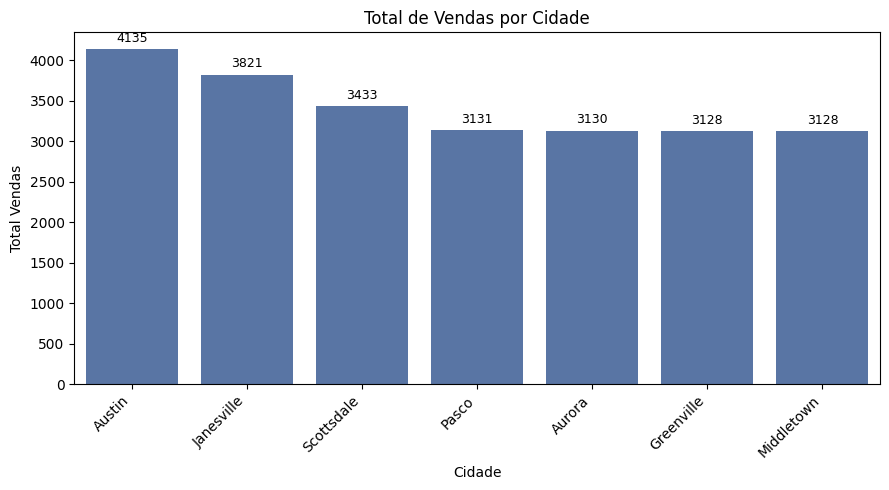

In [ ]:
plt.figure(figsize=(9, 5))

# Contar Car_id por Dealer_Region e ordenar em ordem decrescente
dealer_region_counts = (
    df.groupby('Dealer_Region')['Car_id']
      .nunique()  # contagem distinta de Car_id
      .sort_values(ascending=False)
)

# Gráfico de barras com a ordem definida
ax = sns.barplot(
    x=dealer_region_counts.index,
    y=dealer_region_counts.values,
    color='#4C72B0'
)

# Rótulos e título
plt.title('Total de Vendas por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Total Vendas')

# Rotacionar rótulos do eixo X para melhor leitura
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos nas barras
for p, v in zip(ax.patches, dealer_region_counts.values):
    ax.annotate(f'{int(v)}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

O gráfico de barras mostra que as cidades que mais vendem automóveis são: em primeiro lugar, Austin com 4135 unidades; em segundo, Janesville com 3821 unidades; e em terceiro, Scottsdale com 3433 unidades. As demais cidades apresentam números muito próximos. Pasco e Aurora com 3131 e 3130 respectivemente. Greenville e Middletown apresentam a mesma quantidade 3128.
Fiz uma contagem distinta do Car_id (.nunique()) para evitar contar duplicidades, uma vez que cada Car_id representa uma venda única.

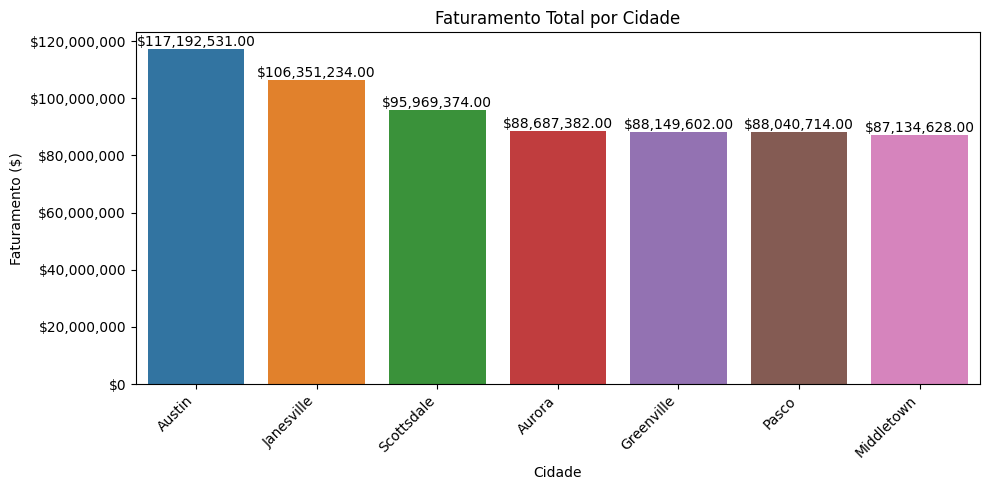

In [ ]:
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 5))
# Calcular o faturamento por cidade
revenue_by_city = df.groupby('Dealer_Region')['Price ($)'].sum().sort_values(ascending=False)

# Criar o gráfico de barras
ax = sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, hue=revenue_by_city.index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Faturamento Total por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Faturamento ($)')

# Adicionar labels no topo das barras com formato de moeda
for container in ax.containers:
    labels = [f'${rect.get_height():,.2f}' for rect in container.get_children()]
    ax.bar_label(container, labels=labels, fmt='')

# Definir o formato do eixo Y para mostrar números inteiros sem abreviação
y_formatter = mticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(y_formatter)

plt.tight_layout()
plt.show()

No gráfico de barras acima, Austin apresenta o maior faturamento, seguido de Janesville e Scottsdale, o que mostra relação direta com a quantidade vendida, conforme visto no gráfico anterior. Contudo, a ordem se altera em relação às demais cidades. Em faturamento, Aurora ocupa quarta posição, Greenville a quinta e Pasco a sexta. Middletown segue na última posição tanto em quantidade quanto em faturamento. As mudanças de posições sugerem que o valor de venda dos automóveis impactam no faturamento dessas cidades.

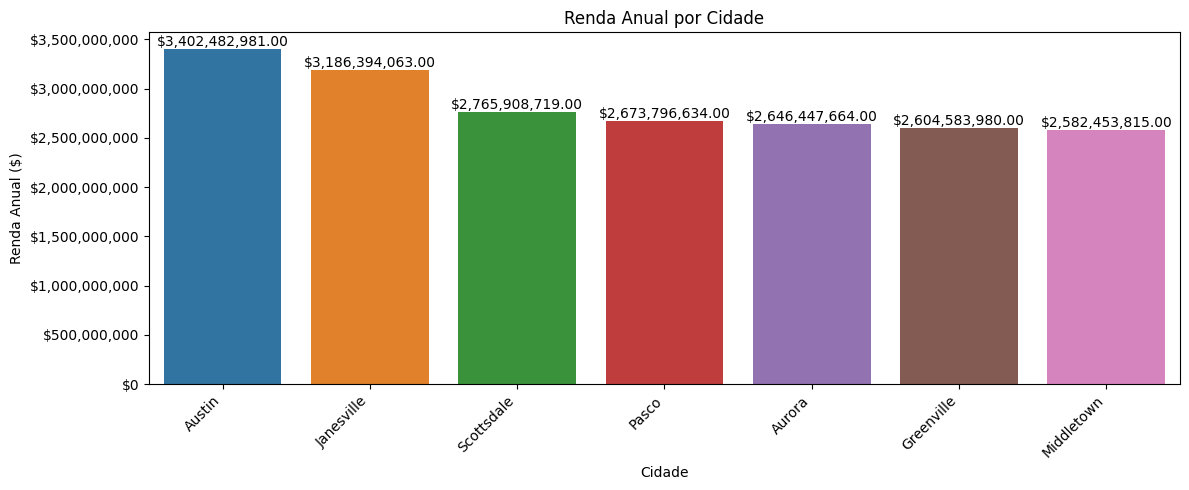

In [ ]:


plt.figure(figsize=(12, 5))
# Calcular a renda anual dos clientes por cidade
revenue_by_city = df.groupby('Dealer_Region')['Annual Income'].sum().sort_values(ascending=False)

# Criar o gráfico de barras
ax = sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, hue=revenue_by_city.index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Renda Anual por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Renda Anual ($)')

# Adicionar labels no topo das barras com formato de moeda
for container in ax.containers:
    labels = [f'${rect.get_height():,.2f}' for rect in container.get_children()]
    ax.bar_label(container, labels=labels, fmt='')

# Definir o formato do eixo Y para mostrar números inteiros sem abreviação
y_formatter = mticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(y_formatter)

plt.tight_layout()
plt.show()

O gráfico de barras acima mostra que a ordem das cidades em relação ao faturamento anual do cliente, do maior para o menor, é a mesma da quantidade vendida. Entretanto, quando comparado com o gráfico de faturamento total por cidade, é possível observar que os clientes de Pasco têm uma renda maior do que Aurora e Greenville, porém gastam menos do que os clientes destas cidades. É possível inferir que os clientes de Aurora e Greenville compram automóveis mais caros mesmo com uma renda menor em relação à Pasco.  

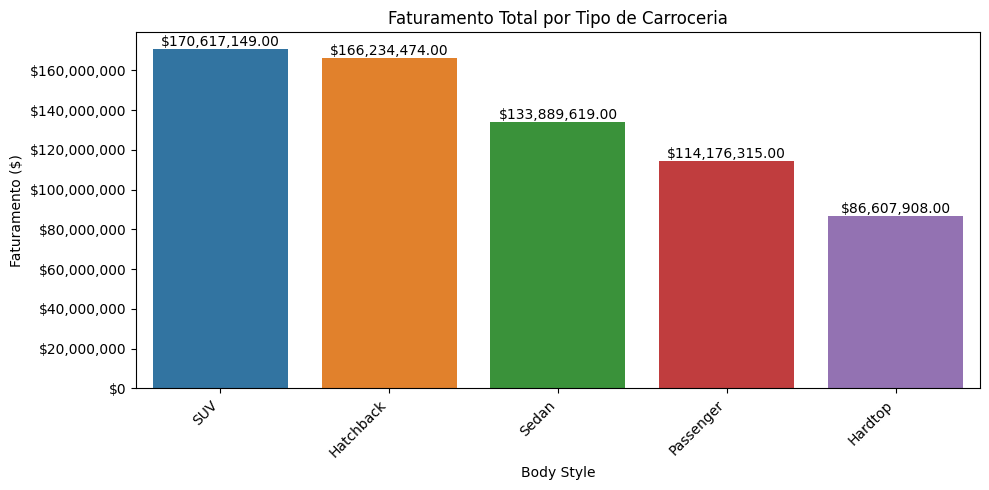

In [ ]:
plt.figure(figsize=(10, 5))
# Calcular o faturamento por cidade
revenue_by_city = df.groupby('Body Style')['Price ($)'].sum().sort_values(ascending=False)

# Criar o gráfico de barras
ax = sns.barplot(x=revenue_by_city.index, y=revenue_by_city.values, hue=revenue_by_city.index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Faturamento Total por Tipo de Carroceria')
plt.xlabel('Body Style')
plt.ylabel('Faturamento ($)')

# Adicionar labels no topo das barras com formato de moeda
for container in ax.containers:
    labels = [f'${rect.get_height():,.2f}' for rect in container.get_children()]
    ax.bar_label(container, labels=labels, fmt='')

# Definir o formato do eixo Y para mostrar números inteiros sem abreviação
y_formatter = mticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(y_formatter)

plt.tight_layout()
plt.show()

De acordo com o gráfico acima, SUV é tipo com o maior faturamento, seguido por Hatchback e Sedan.

In [ ]:


# Garantir que Price ($) é numérico
df['Price ($)'] = (
    df['Price ($)']
      .astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
      .astype(float)
)

# Agregações por Company
summary = df.groupby('Company').agg(
    Count=('Car_id', 'count'),
    Sum_Price=('Price ($)', 'sum')
)

# Body Style mais frequente por Company (moda)
body_mode = (
    df.groupby('Company')['Body Style']
      .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
)

# Mesclar Body Style
summary = summary.join(body_mode.rename('Body Style'))

# Ordenar por faturamento
summary = summary.sort_values('Sum_Price', ascending=False)

# Percentual do faturamento
total_faturamento = summary['Sum_Price'].sum()
summary['%_Faturamento'] = (summary['Sum_Price'] / total_faturamento * 100).map(lambda x: f'{x:.2f}%')

print("Matriz por Marca e Tipo Carroceria mais frequente: total vendido, total faturamento e % do faturamento (ordenada por faturamento):")
print(summary)


Matriz por Marca e Tipo Carroceria mais frequente: total vendido, total faturamento e % do faturamento (ordenada por faturamento):
            Count   Sum_Price Body Style %_Faturamento
Company                                               
Chevrolet    1819  47655265.0        SUV         7.10%
Ford         1614  47231583.0        SUV         7.03%
Dodge        1671  44124996.0        SUV         6.57%
Oldsmobile   1111  35434512.0      Sedan         5.28%
Mercedes-B   1285  34624123.0        SUV         5.16%
Volkswagen   1333  34082881.0  Hatchback         5.08%
Mitsubishi   1277  34062466.0  Hatchback         5.07%
Toyota       1110  32759564.0  Hatchback         4.88%
Chrysler     1120  29141873.0  Hatchback         4.34%
Lexus         802  27287703.0      Sedan         4.06%
Cadillac      652  26713805.0  Passenger         3.98%
Mercury       874  24939733.0        SUV         3.71%
Nissan        886  23964095.0  Hatchback         3.57%
Pontiac       796  23369207.0      Sedan    

Conforme matriz acima, a Chevrolet ocupa a liderança tanto em volume quanto em faturamento. Contudo, algumas marcas vendem menos mas faturam mais que outras, como observado entre a Ford e a Dodge, e Mercedes e Oldsmobile em relação à Volkswagen. Para cada marca também é observado o tipo de carroceria mais vendida com destaque para o SUV.

In [ ]:

import plotly.graph_objects as go

# Pipeline de preparo
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()
df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')

dfg = (df.groupby(['YearMonth', 'Dealer_Region'], as_index=False)['Price ($)']
         .mean().rename(columns={'Price ($)': 'AvgPrice'}))

regions = sorted(dfg['Dealer_Region'].dropna().unique())

fig = go.Figure()

# Uma trace por região
for r in regions:
    dfr = dfg[dfg['Dealer_Region'] == r]
    fig.add_trace(go.Scatter(
        x=dfr['YearMonth'],
        y=dfr['AvgPrice'],
        mode='lines+markers',
        name=r,
        visible=True
    ))

# Dropdown: Todas / Nenhuma / Individual (opcional)
buttons = [
    dict(label='Todas', method='update', args=[{'visible': [True]*len(regions)}]),
    dict(label='Nenhuma', method='update', args=[{'visible': [False]*len(regions)}]),
]
for i, r in enumerate(regions):
    vis = [False]*len(regions); vis[i] = True
    buttons.append(dict(label=r, method='update', args=[{'visible': vis}]))

fig.update_layout(
    title='Faturamento Médio por Cidade ao Longo do Tempo',
    xaxis_title='Data (yyyy/MM)',
    yaxis_title='Média de Price ($)',
    xaxis=dict(tickformat='%Y/%m'),
    updatemenus=[dict(type='dropdown', x=1.15, y=1.1, showactive=True, buttons=buttons)]
)

fig.show()

O gráfico acima mostra o faturamento médio por cidade ao longo do tempo com o eixo X mostrando o avanço de 3 em 3 meses. Conforme o gráfico mostra nenhuma cidade apresenta um faturamento estável, pelo contrário, todas apresentam picos e declínios dentro de um intervalo de USD 24k a USD 32k. Entretanto, olhando de perto o último trimestre os valores médios estão mais próximos porém Greenville e Janesville apresentam tendência de queda enquanto que as demais tendência de crescimento.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset, excluindo a coluna 'Phone, Date e YearMonth'
df.drop(columns=['Phone', 'Date', 'YearMonth']).describe()

,Annual Income,Price ($)
count,2.390600e+04,23906.000000
mean,8.308403e+05,28090.247846
std,7.200064e+05,14788.687608
min,1.008000e+04,1200.000000
25%,3.860000e+05,18001.000000
50%,7.350000e+05,23000.000000
75%,1.175750e+06,34000.000000
max,1.120000e+07,85800.000000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
# média dos atributos numéricos do dataset
df.drop(columns=['Phone', 'Date', 'YearMonth']).describe().loc['mean']


,mean
Annual Income,830840.285117
Price ($),28090.247846


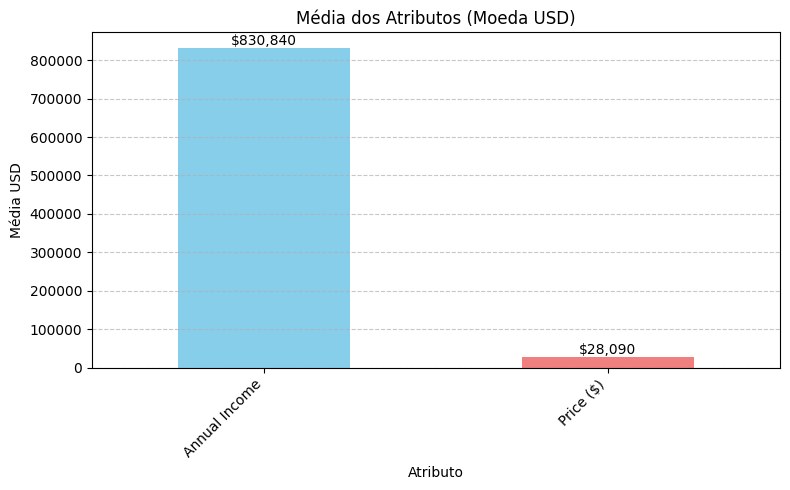

In [ ]:
mean_values = df.drop(columns=['Phone', 'Date', 'YearMonth']).describe().loc['mean']

plt.figure(figsize=(8, 5))
mean_values.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Média dos Atributos (Moeda USD)')
plt.xlabel('Atributo')
plt.ylabel('Média USD')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras com '$'
for index, value in enumerate(mean_values):
    plt.text(index, value, f'${value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

O gráfico acima mostra que na média a renda é bem maior do que a média dos preços dos automóveis, o que confirma o poder de compra dos clientes destas cidades.

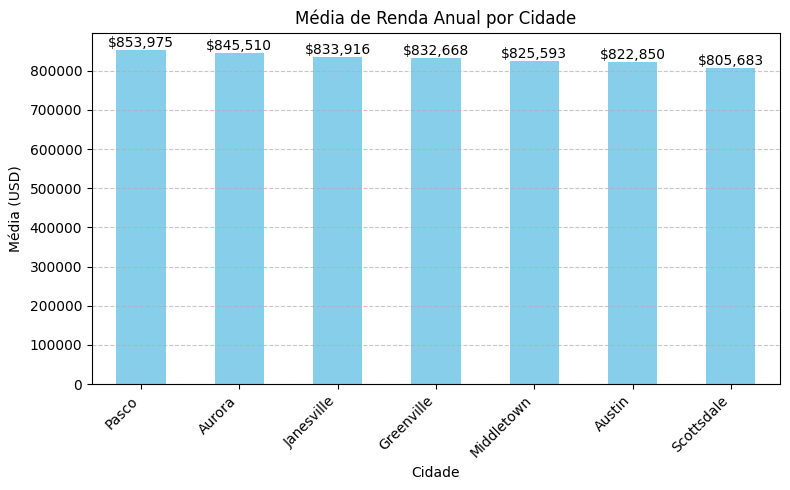

In [ ]:
# Calcular a média de Annual Income por Dealer_Region
mean_values = (
    df.groupby('Dealer_Region')['Annual Income']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = mean_values.plot(kind='bar', color='skyblue')

plt.title('Média de Renda Anual por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Média (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras com formatação em dólar
for i, value in enumerate(mean_values.values):
    plt.text(i, value, f'${value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Conforme acima, Pasco apresenta a maior média de Renda Anual. É possível observar, em termos de média da Renda Anual, uma certa igualdade entre as cidades, o que mostra que, até então, todas as cidades tem bom potencial de venda, uma vez que seus clientes têm poder de compra.

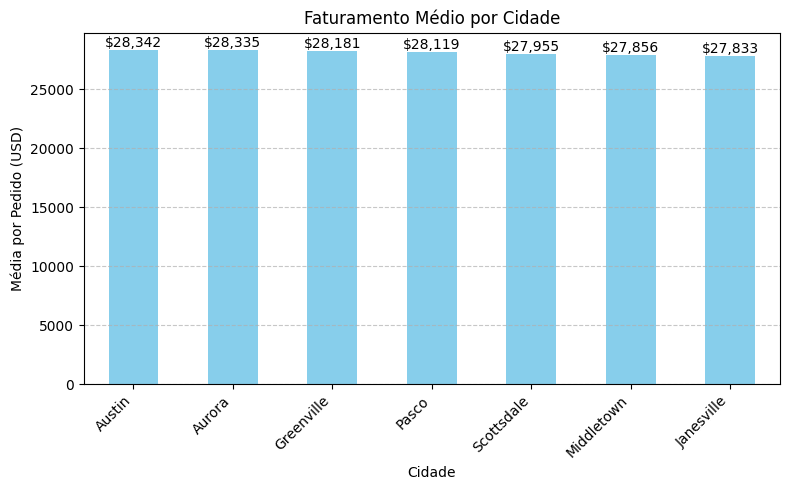

In [ ]:
# Somar o faturamento por pedido dentro de cada região
order_revenue = (
    df.groupby(['Dealer_Region', 'Car_id'])['Price ($)']
      .sum()
      .reset_index(name='order_revenue')
)

# Média das somas por região
mean_values = (
    order_revenue.groupby('Dealer_Region')['order_revenue']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = mean_values.plot(kind='bar', color='skyblue')

plt.title('Faturamento Médio por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Média por Pedido (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(mean_values.values):
    plt.text(i, value, f'${value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Acima foi calculado o faturamento médio por cidade, mostrando um certo equilíbrio das médias entre as cidades. Por esse análise Austin aparece como a cidade mais lucrativa mesmo tendo a segunda menor renda anual entre as demais cidades.

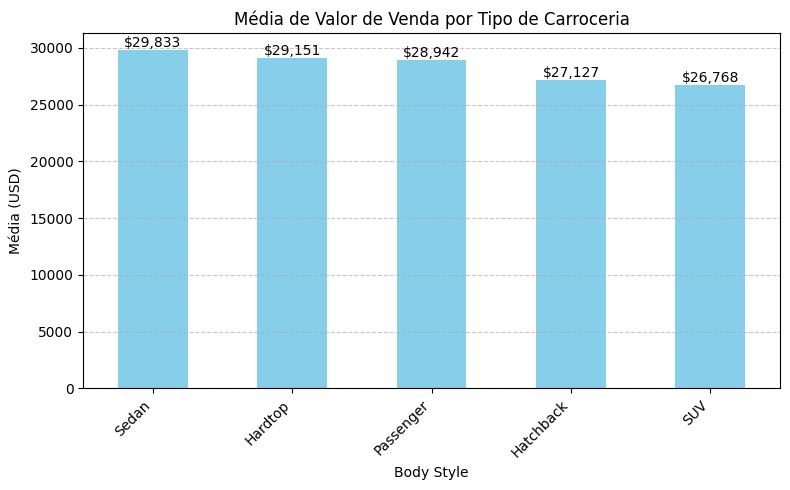

In [ ]:
# Calcular a média de Annual Income por Dealer_Region
mean_values = (
    df.groupby('Body Style')['Price ($)']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
ax = mean_values.plot(kind='bar', color='skyblue')

plt.title('Média de Valor de Venda por Tipo de Carroceria')
plt.xlabel('Body Style')
plt.ylabel('Média (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras com formatação em dólar
for i, value in enumerate(mean_values.values):
    plt.text(i, value, f'${value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

No gráfico é possível verificar que o automóvel do tipo 'Sedan' tem o maior média de valor de venda, seguido do 'Hardtop' e 'Passenger'. Fiquei surpreso com o tipo 'SUV' com a menor média apesar de ter o maior faturamento, como visto em gráfico anterior. Isso indica que se as lojas querem adotar uma estratégia de vender em grande quantidade, SUVs podem ser o melhor produto para ofertar; se a estratégia é ter uma margem de lucro maior e menor volume, o tipo Sedan tende a ser o melhor produto a ser ofertado.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
df.drop(columns=['Phone','Date', 'YearMonth']).describe().loc['std']

,std
Annual Income,720006.395388
Price ($),14788.687608


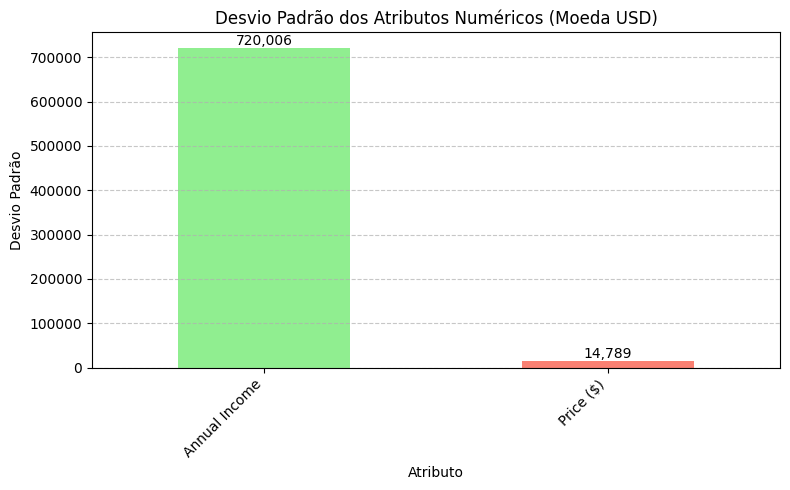

In [ ]:
std_values = df.drop(columns=['Phone', 'Date', 'YearMonth']).describe().loc['std']

plt.figure(figsize=(8, 5))
std_values.plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Desvio Padrão dos Atributos Numéricos (Moeda USD)')
plt.xlabel('Atributo')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras sem '$'
for index, value in enumerate(std_values):
    plt.text(index, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Como visto acima no gráfico o desvio padrão está bem alto para os dois atributos, principalmente 'Annual Income', o que mostra uma dispersão bem grande entre os valores de renda dos clientes, ou seja, do ponto de vista de renda, existe uma clientela bastante heterogênea. Isso indica a presença de outliers. Em relação ao Price ($), é plausível tendo em vista a variedade de marcas, modelos e características mecânicas e de design.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Annual Income*

Análise de Annual Income no histograma.

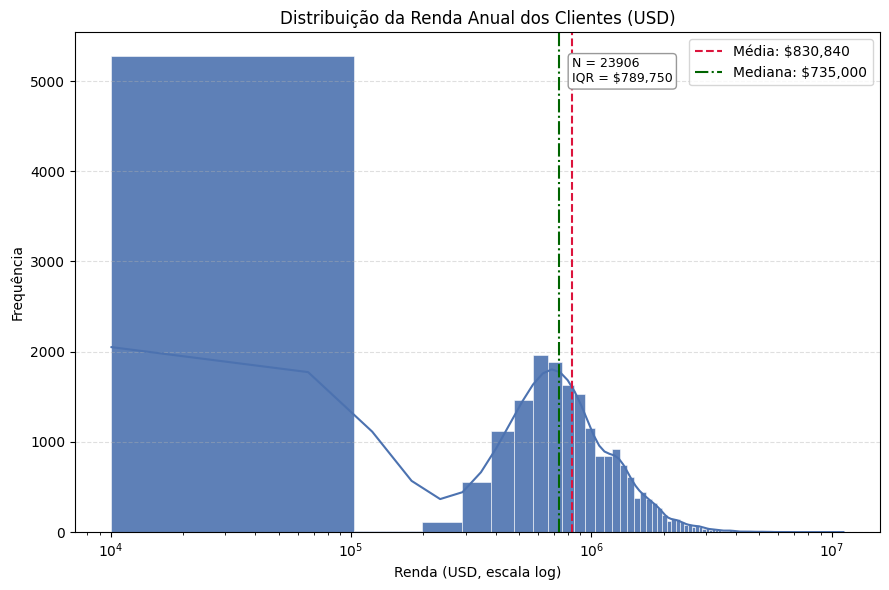

In [ ]:
# Remover valores nulos
income = df['Annual Income'].dropna()

# Remover valores negativos (por segurança)
income = income[income >= 0]

# Cálculo de estatísticas
mean_val = income.mean()
median_val = income.median()

# Definir número de bins (Freedman–Diaconis)
q1, q3 = np.percentile(income, [25, 75])
iqr = q3 - q1
n = len(income)
bin_width = 2 * iqr / (n ** (1/3)) if iqr > 0 else None

if bin_width and bin_width > 0:
    bins = int(np.clip((income.max() - income.min()) / bin_width, 20, 120))
else:
    bins = 50  # fallback

plt.figure(figsize=(9, 6))
ax = sns.histplot(
    income,
    bins=bins,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.9
)

# Título e rótulos
plt.title('Distribuição da Renda Anual dos Clientes (USD)')
plt.xlabel('Renda (USD)')
plt.ylabel('Frequência')

# Linhas de média e mediana
plt.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Média: ${mean_val:,.0f}')
plt.axvline(median_val, color='darkgreen', linestyle='-.', linewidth=1.5, label=f'Mediana: ${median_val:,.0f}')

#Escala log no eixo X para cauda longa
plt.xscale('log')
if plt.gca().get_xscale() == 'log':
       plt.xlabel('Renda (USD, escala log)')

# Grade e estilo
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Anotar estatísticas principais
text_x = mean_val if mean_val < income.max() else income.quantile(0.9)
plt.text(text_x, plt.ylim()[1]*0.9,
         f'N = {n}\nIQR = ${iqr:,.0f}',
         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#999'))

plt.legend()
plt.tight_layout()
plt.show()

De acordo com o histograma acima, a faixa de renda entre USD 10,000.00 a USD 100,000.00 aparece com mais frequência, acima de 5000 casos, enquanto que a frequência para quem ganha acima de USD 1,000,000.00 fica abaixo de 1000 casos. Fica claro a disparidade de renda presente nesse dataset.

### *Price ($)*

Análise de Price ($) no histograma.

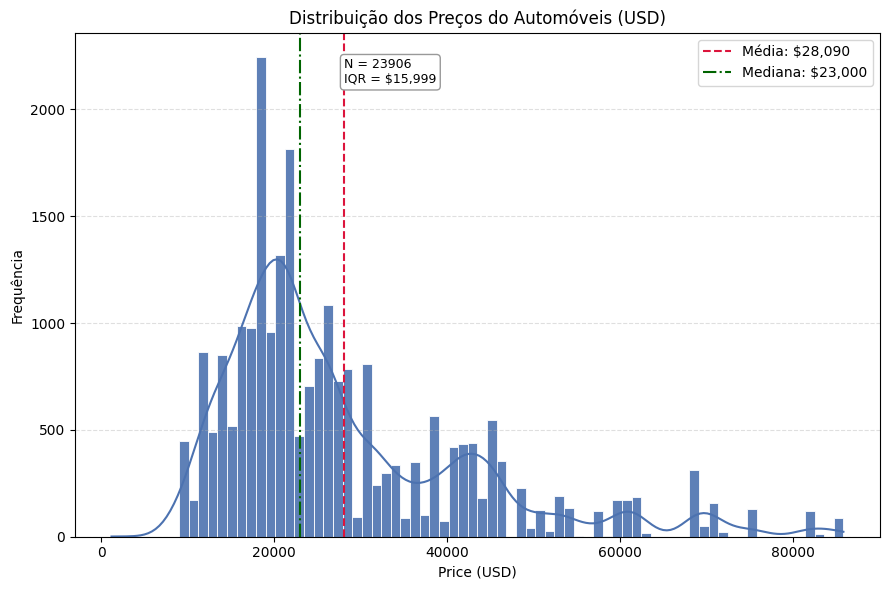

In [ ]:
# Remover valores nulos
price = df['Price ($)'].dropna()

# Remover valores negativos (por segurança)
price = price[price >= 0]

# Cálculo de estatísticas
mean_val = price.mean()
median_val = price.median()

# Definir número de bins (Freedman–Diaconis)
q1, q3 = np.percentile(price, [25, 75])
iqr = q3 - q1
n = len(price)
bin_width = 2 * iqr / (n ** (1/3)) if iqr > 0 else None

if bin_width and bin_width > 0:
    bins = int(np.clip((price.max() - price.min()) / bin_width, 20, 120))
else:
    bins = 50  # fallback

plt.figure(figsize=(9, 6))
ax = sns.histplot(
    price,
    bins=bins,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.9
)

# Título e rótulos
plt.title('Distribuição dos Preços do Automóveis (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequência')

# Linhas de média e mediana
plt.axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5, label=f'Média: ${mean_val:,.0f}')
plt.axvline(median_val, color='darkgreen', linestyle='-.', linewidth=1.5, label=f'Mediana: ${median_val:,.0f}')

#Escala log no eixo
#plt.xscale('log')
#if plt.gca().get_xscale() == 'log':
       #plt.xlabel('Renda (USD, escala log)')

# Grade e estilo
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Anotar estatísticas principais
text_x = mean_val if mean_val < price.max() else price.quantile(0.9)
plt.text(text_x, plt.ylim()[1]*0.9,
         f'N = {n}\nIQR = ${iqr:,.0f}',
         fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#999'))

plt.legend()
plt.tight_layout()
plt.show()

As impressões sobre a distribuição do atributo 'Price':
- heterogeneidade dos preços, tendo em vista a diversidade dos carros ofertados;
- uma frequência maior na faixa de USD 15,000.00 a USD 40,000.00;
- poucos automóveis custando acima de USD 60,000.00
- essas observações mostram que os preços praticados por esses automóveis nessas cidades estão compatíveis com o nível de renda da clientela.

## Boxplot

Para entender as diferenças entre as cidades, devemos olhar como se comportam os valores quando agrupadas por cidade. Isso nos permite comparar a média, mediana e desvio padrão de cada característica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por cidade
df_sem_phone = df.drop(columns=['Phone', 'YearMonth', 'Date'])
df_sem_phone.groupby('Dealer_Region').describe()

Annual Income                                                   \
                      count           mean            std      min       25%   
Dealer_Region                                                                  
Aurora               3130.0  845510.435783  740832.368692  13500.0  400000.0   
Austin               4135.0  822849.572189  745977.517121  13500.0  375000.0   
Greenville           3128.0  832667.512788  721553.702435  13500.0  385000.0   
Janesville           3821.0  833916.268778  706807.675694  13500.0  385000.0   
Middletown           3128.0  825592.651854  700461.495107  13500.0  396750.0   
Pasco                3131.0  853975.290323  728473.654154  10080.0  404000.0   
Scottsdale           3433.0  805682.702884  690885.629181  13500.0  360000.0   

                                               Price ($)                \
                    50%        75%         max     count          mean   
Dealer_Region                                                            
Aurora         741000.0  1188000.0   7650000.0    3130.0  28334.626837   
Austin         726000.0  1125500.0  11200000.0    4135.0  28341.603628   
Greenville     750000.0  1190000.0   6800000.0    3128.0  28180.819054   
Janesville     745000.0  1190000.0   5500000.0    3821.0  27833.350955   
Middletown     725000.0  1185000.0   6400000.0    3128.0  27856.338875   
Pasco          745000.0  1205000.0   6460000.0    3131.0  28119.039923   
Scottsdale     720000.0  1152000.0   6240000.0    3433.0  27954.958928   

                                                                         
                        std     min      25%      50%      75%      max  
Dealer_Region                                                            
Aurora         15026.207252  9000.0  18001.0  23000.0  35000.0  85800.0  
Austin         14903.884549  9000.0  18001.0  23801.0  35001.0  85601.0  
Greenville     15101.538328  1200.0  18001.0  22500.0  34500.0  85200.0  
Janesville     14344.995638  4300.0  18001.0  23000.0  34000.0  85400.0  
Middletown     14619.842395  1700.0  18000.0  22750.0  34000.0  85300.0  
Pasco          14659.315941  9000.0  18500.5  23000.0  34000.0  85600.0  
Scottsdale     14902.916820  1450.0  18000.0  22600.0  33500.0  85001.0

### *Renda Anual* por Cidade


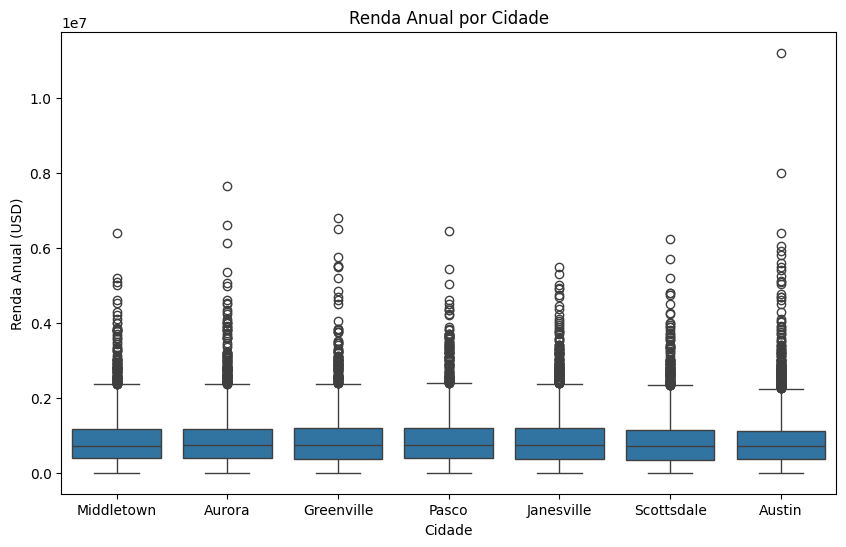

In [ ]:
# Boxplot da renda anual por cidade
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dealer_Region', y='Annual Income', data=df)
plt.title('Renda Anual por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Renda Anual (USD)')
plt.show()

Presença de outliers em todas as cidades mas Austin fica bem evidente, com cliente com renda superior a USD10,000,000.00

### *Preço dos automóveis* por Cidade

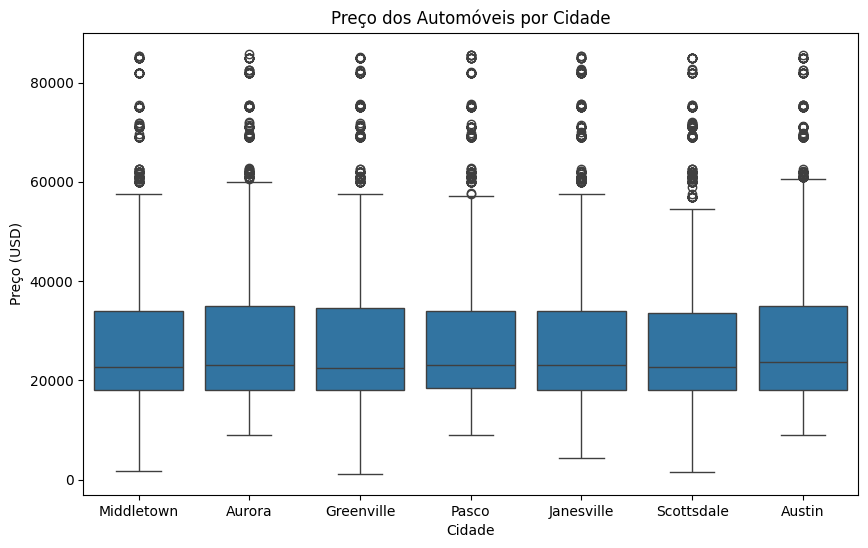

In [ ]:
# Boxplot do preço dos automóveis por cidade
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dealer_Region', y='Price ($)', data=df)
plt.title('Preço dos Automóveis por Cidade')
plt.xlabel('Cidade')
plt.ylabel('Preço (USD)')
plt.show()

No boxplot acima fica nítido a faixa de preço dos automóveis na casa de USD 20k a USD 40K. Existem outliers na faixa de USD 80k.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

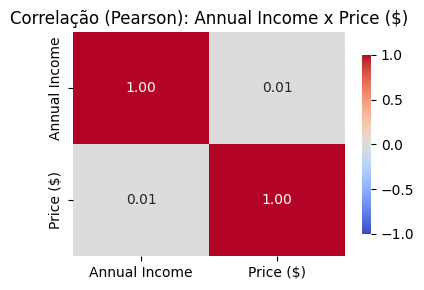

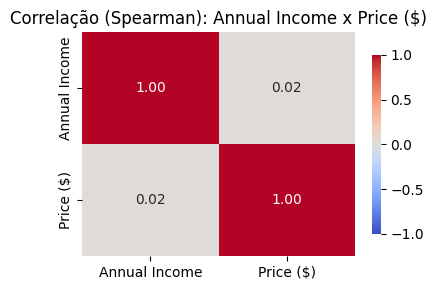

Matriz Pearson:
                Annual Income  Price ($)
Annual Income       1.000000   0.012065
Price ($)           0.012065   1.000000
Matriz Spearman:
                Annual Income  Price ($)
Annual Income       1.000000   0.016723
Price ($)           0.016723   1.000000


In [ ]:
# Análise com colunas/atributos numéricos

# 1) Converter colunas numéricas
df['Annual Income'] = pd.to_numeric(df['Annual Income'], errors='coerce')
df['Price ($)']     = pd.to_numeric(df['Price ($)'], errors='coerce')

# 2) Selecionar apenas as colunas de interesse
num_cols = ['Annual Income', 'Price ($)']
df_num = df[num_cols].dropna()

# 3) Matriz de correlação (Pearson por padrão)
corr_pearson = df_num.corr(method='pearson')

# 4) Calcular Spearman (diminuir o efeito de outliers)
corr_spearman = df_num.corr(method='spearman')

# 5) Plot: heatmap Pearson
plt.figure(figsize=(4, 3))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlação (Pearson): Annual Income x Price ($)')
plt.tight_layout()
plt.show()

# 6) Plot: heatmap Spearman
plt.figure(figsize=(4, 3))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlação (Spearman): Annual Income x Price ($)')
plt.tight_layout()
plt.show()

# 7) Exibir os valores em texto
print('Matriz Pearson:\n', corr_pearson)
print('Matriz Spearman:\n', corr_spearman)

Acima foram adotadas duas abordagens para correlação entre as variáveis/atributos numéricos: Pearson e Spearman, 0.012 e 0.016 respectivamente. Considerando o dataset como um todo, o resultado mostra que não há evidência de que clientes com renda maior comprem automóveis mais caros ou mais baratos de forma consistente.

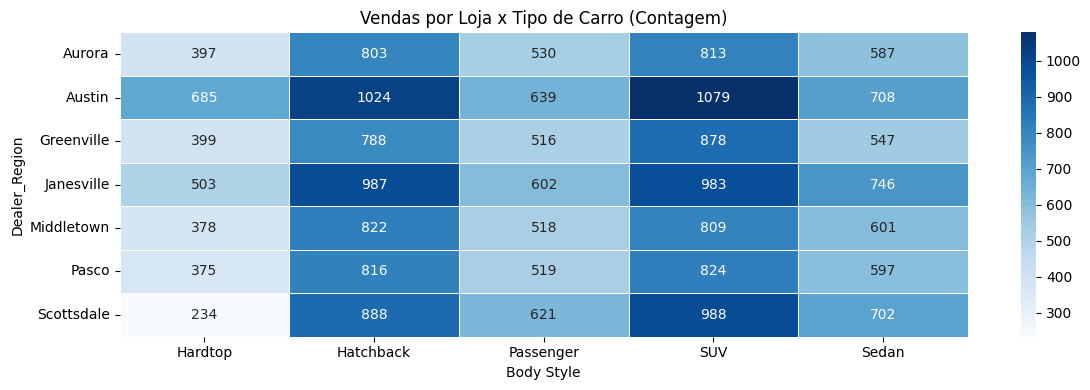

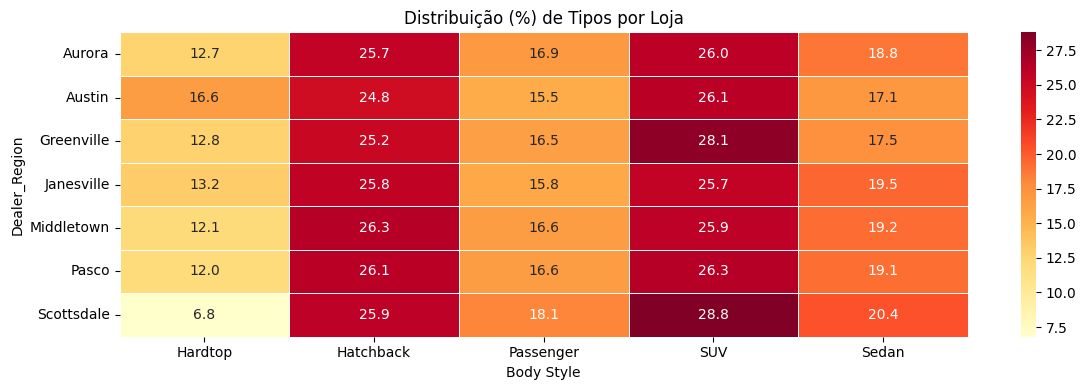

In [ ]:

# Tratar textos vazios/NaN
d = df[['Dealer_Region', 'Body Style']].copy()
d = d.dropna(subset=['Dealer_Region', 'Body Style'])

# 1) Tabela de contingência: contagem de vendas por Loja x Tipo
ct_counts = pd.crosstab(d['Dealer_Region'], d['Body Style'])

# 2) Heatmap de contagem bruta
plt.figure(figsize=(12, max(4, 0.4 * ct_counts.shape[0])))
sns.heatmap(
    ct_counts,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white'
)
plt.title('Vendas por Loja x Tipo de Carro (Contagem)')
plt.xlabel('Body Style')
plt.ylabel('Dealer_Region')
plt.tight_layout()
plt.show()

# 3) Heatmap de percentuais por loja (normalizado por linha)
ct_rowpct = ct_counts.div(ct_counts.sum(axis=1).replace(0, 1), axis=0) * 100

plt.figure(figsize=(12, max(4, 0.4 * ct_rowpct.shape[0])))
sns.heatmap(
    ct_rowpct.round(1),
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white'
)
plt.title('Distribuição (%) de Tipos por Loja')
plt.xlabel('Body Style')
plt.ylabel('Dealer_Region')
plt.tight_layout()
plt.show()

Conforme heatmap acima, o tipo SUV e Hatchback são os modelos mais vendidos em todas as lojas, revelando a preferência do consumidor.

Renda por tipo (ordenado pela mediana):
                n           mean    median            std       q25        q75
Body Style                                                                   
Hatchback   6128  851174.051893  760000.0  727096.942204  392875.0  1217500.0
Sedan       4488  829198.641711  742250.0  717186.477904  379500.0  1170000.0
Hardtop     2971  821333.736116  725000.0  690727.317236  420600.0  1117500.0
Passenger   3945  820355.502408  720000.0  717366.610522  360000.0  1177000.0
SUV         6374  823367.551773  720000.0  729900.878453  380000.0  1152375.0


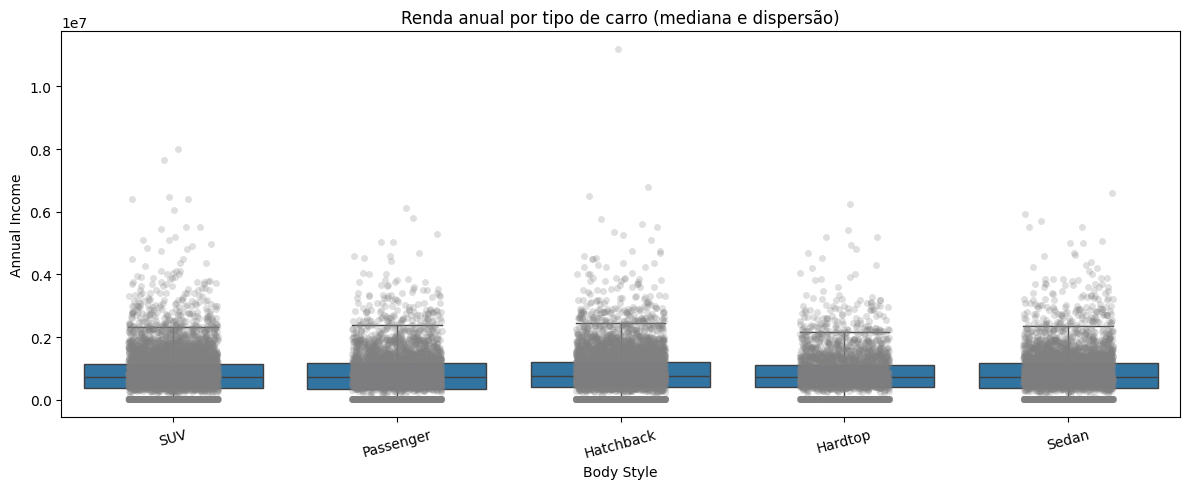

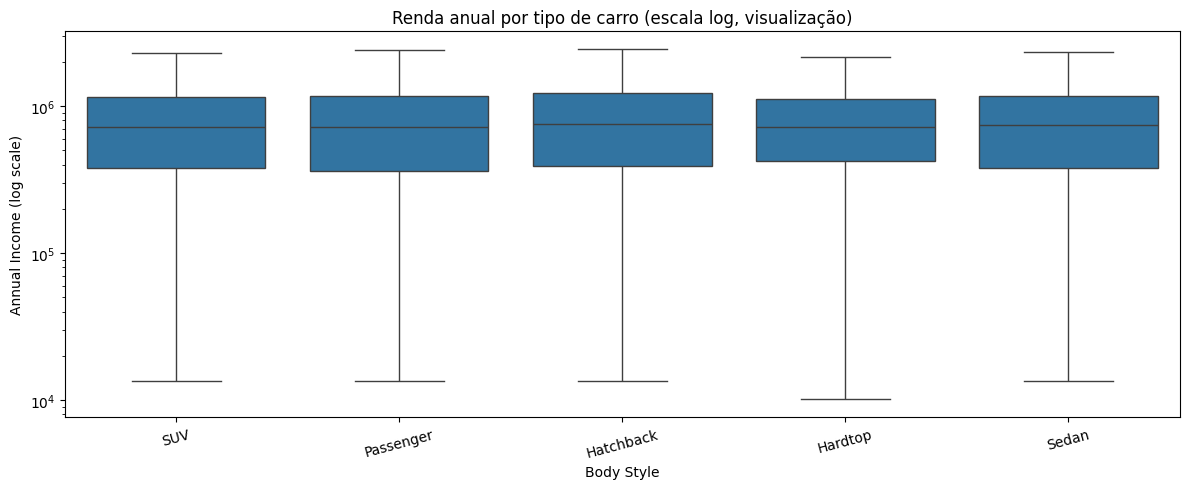

Kruskal–Wallis: H=13.549, p-value=0.00888
Efeito (Kruskal epsilon-squared): ε²=0.000  (≈0 baixo; 0.01 pequeno; 0.06 médio; 0.14 grande)
Post-hoc Dunn (p-values ajustados):
             Hardtop  Hatchback  Passenger       SUV     Sedan
Hardtop    1.000000   0.349726   1.000000  1.000000  1.000000
Hatchback  0.349726   1.000000   0.032498  0.012248  0.677723
Passenger  1.000000   0.032498   1.000000  1.000000  1.000000
SUV        1.000000   0.012248   1.000000  1.000000  1.000000
Sedan      1.000000   0.677723   1.000000  1.000000  1.000000

Ranking por renda mediana (com Q1–Q3 e n):
               median       q25        q75     n
Body Style                                     
Hatchback   760000.0  392875.0  1217500.0  6128
Sedan       742250.0  379500.0  1170000.0  4488
Hardtop     725000.0  420600.0  1117500.0  2971
Passenger   720000.0  360000.0  1177000.0  3945
SUV         720000.0  380000.0  1152375.0  6374


In [ ]:
!pip install scikit-posthocs -q
from scipy import stats
import scikit_posthocs as sp

# colunas: 'Annual Income' (numérica ou texto) e 'Body Style' (categórica)
d = df[['Annual Income', 'Body Style']].copy()
d['Annual Income'] = pd.to_numeric(d['Annual Income'], errors='coerce')
d = d.dropna(subset=['Annual Income', 'Body Style'])

# 1) Resumo por tipo: contagem, média, mediana, desvio-padrão
summary = (
    d.groupby('Body Style')['Annual Income']
      .agg(n='count', mean='mean', median='median', std='std', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
      .sort_values('median', ascending=False)
)
print('Renda por tipo (ordenado pela mediana):\n', summary)

# 2) Visualizações
plt.figure(figsize=(12, 5))
sns.boxplot(data=d, x='Body Style', y='Annual Income', showfliers=False)
sns.stripplot(data=d, x='Body Style', y='Annual Income', color='gray', alpha=0.25, jitter=0.2)
plt.title('Renda anual por tipo de carro (mediana e dispersão)')
plt.xlabel('Body Style'); plt.ylabel('Annual Income')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Alternativa robusta a outliers: usar escala log para visualização
plt.figure(figsize=(12, 5))
sns.boxplot(data=d, x='Body Style', y='Annual Income', showfliers=False)
plt.yscale('log')
plt.title('Renda anual por tipo de carro (escala log, visualização)')
plt.xlabel('Body Style'); plt.ylabel('Annual Income (log scale)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 3) Teste global de diferenças entre grupos
# Escolha do teste:
# - ANOVA se distribuição ~normal/homoscedástica (raro em renda).
# - Kruskal–Wallis (não-paramétrico) é mais seguro para renda com outliers.

groups = [g['Annual Income'].values for _, g in d.groupby('Body Style') if len(g) > 1]
if len(groups) >= 2:
    # Kruskal–Wallis
    H, p_kw = stats.kruskal(*groups)
    print(f'Kruskal–Wallis: H={H:.3f}, p-value={p_kw:.3g}')
else:
    print('Grupos insuficientes para teste (menos de 2 grupos com n>1).')

# 4) Medida de efeito (quanto a categórica explica da variância da renda)
# Eta-squared para ANOVA clássica; para Kruskal, use epsilon-squared (ε²) aproximado.
# Aqui calculamos epsilon-squared para Kruskal–Wallis:
n_total = len(d)
k = d['Body Style'].nunique()

if len(groups) >= 2:
    eps2 = (H - (k - 1)) / (n_total - 1)  # epsilon-squared
    print(f'Efeito (Kruskal epsilon-squared): ε²={eps2:.3f}  (≈0 baixo; 0.01 pequeno; 0.06 médio; 0.14 grande)')

# 5) Post-hoc: onde estão as diferenças? (Dunn com correção de múltiplas comparações)
if len(groups) >= 2 and p_kw < 0.05:
    posthoc = sp.posthoc_dunn(d, val_col='Annual Income', group_col='Body Style', p_adjust='bonferroni')
    print('Post-hoc Dunn (p-values ajustados):\n', posthoc)

# 6) Ranking dos tipos por renda (mediana)
ranking = summary[['median', 'q25', 'q75', 'n']].sort_values('median', ascending=False)
print('\nRanking por renda mediana (com Q1–Q3 e n):\n', ranking)

Acima foi testado a seguinte correlação entre a renda anual e o tipo de carro, buscando verificar qual tipo de carro os clientes com maior renda compram. Abaixo as análises:

Teste global (Kruskal–Wallis): H=13.549, p=0.00888

Há evidência estatística de diferença de renda entre pelo menos dois tipos de carro.

Tamanho de efeito: ε²≈0.000
Apesar de significante, o efeito é praticamente nulo em termos práticos. A diferença explicada pelo “tipo” sobre a renda é desprezível quando comparada à variabilidade total.

Post-hoc (Dunn, p-ajustado Bonferroni):

Diferenças significativas apenas envolvendo Hatchback:

Hatchback vs Hatchback: —

Hatchback vs Passenger: p=0.0325

Hatchback vs SUV: p=0.0122

Os demais pares não apresentaram diferenças significativas após ajuste.
Ranking por renda mediana (Q1–Q3 e n):

Hatchback: mediana 760.000 (Q1 392.875; Q3 1.217.500; n=6.128)

Sedan: 742.250 (379.500; 1.170.000; n=4.488)

Hardtop: 725.000 (420.600; 1.117.500; n=2.971)

Passenger: 720.000 (360.000; 1.177.000; n=3.945)

SUV: 720.000 (380.000; 1.152.375; n=6.374)

Conclusão:

Consumidores que compram Hatchback têm renda mediana ligeiramente maior que os de Passenger e SUV; a diferença é estatisticamente significativa, mas muito pequena no contexto geral (ε²≈0).
Entre os demais tipos (Sedan, Hardtop, Passenger, SUV), as diferenças não são estatisticamente robustas após correção múltipla.
Portanto, o tipo de carro tem impacto estatisticamente detectável, porém muito fraco, na renda dos compradores. Em termos de negócio, não há um “perfil de renda” marcante por tipo — exceção sutil para Hatchbacks com renda um pouco mais alta.

## Tratamento de Valores Nulos

O dataset Car Sales Report possui apenas 1 valor nulo no atributo 'Customer Name'. Para esta análise esse atributo não é levado em consideração. Se estivesse considerando uma análise específica por cliente, esse valor nulo poderia ser resolvido de 2 formas: primeiro, como o valor de telefone (Phone) está preenchido tentaria buscar em alguma base de dados de cadastro de clientes e usaria o Phone como chave de relacionamento; a segunda opção, caso a primeira não seja possível, seria excluir essa linha do Dataset.

O tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Car Sales Report:")
df.isnull().sum()

Valores nulos no dataset Car Sales Report:


,0
Car_id,0
Date,0
Customer Name,1
Gender,0
Annual Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


In [ ]:
#Tratamento de valores Nulos preenchendo com a Moda

def fillna_with_mode(df: pd.DataFrame) -> pd.DataFrame:
    df_filled = df.copy()
    modes_info = {}

    for col in df_filled.columns:
        # Calcula a(s) moda(s) ignorando NaN
        mode_series = df_filled[col].mode(dropna=True)

        if mode_series.empty:
            # Coluna inteira NaN ou sem moda definida
            modes_info[col] = {'mode': None, 'filled': 0}
            continue

        mode_value = mode_series.iloc[0]
        n_missing = df_filled[col].isna().sum()

        # Converte tipos se necessário para evitar problemas de comparação
        try:
            df_filled[col] = df_filled[col].fillna(mode_value)
        except Exception:
            # Como fallback, converte para string (especialmente útil em colunas mistas)
            df_filled[col] = df_filled[col].astype('object').fillna(str(mode_value))

        modes_info[col] = {'mode': mode_value, 'filled': int(n_missing)}

    return df_filled, pd.DataFrame(modes_info).T

# Uso:
df_filled, report = fillna_with_mode(df)
print('Resumo do preenchimento por coluna:')
print(report)

Resumo do preenchimento por coluna:
                                                          mode filled
Car_id                                            C_CND_000001      0
Date                                       2023-09-05 00:00:00      0
Customer Name                                           Thomas      1
Gender                                                    Male      0
Annual Income                                            13500      0
Dealer_Name    Progressive Shippers Cooperative Association No      0
Company                                              Chevrolet      0
Model                                                 Diamante      0
Engine                               DoubleÂ Overhead Camshaft      0
Transmission                                              Auto      0
Color                                               Pale White      0
Price ($)                                              22000.0    0.0
Dealer_No                                           85

Acima foi criado o código para tratar valores nulos. Optei por preencher os valores nulos com a moda para ter menos impacto de outliers.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

Objetivo: modelo supervisionado de regressão para prever o faturamento futuro por cidade.

Observações:
- Faturamento = soma de Price ($) por cidade em um período (ex.: mês)
- Target: faturamento mensal por cidade
- Agregar vendas por cidade (Dealer_Region) e mês


In [ ]:
#Preparação: converter tipos e limpeza
 #'Date' para datetime;
 #'Price ($)' para numérico;
 # Remover linhas com Date, Price ($) ou Dealer_Region nulos
# Criar coluna mensal

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')

df = df.dropna(subset=['Date', 'Price ($)', 'Dealer_Region'])
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

Faturamento: soma de Price ($) por cidade em um período (mês)

In [ ]:
# O target será a coluna 'revenue' do df agregado
agg = (
    df.groupby(['Dealer_Region', 'YearMonth'])
      .agg(revenue=('Price ($)', 'sum'))
      .reset_index()
)

Agregar vendas por cidade (Dealer_Region) e mês

In [ ]:
agg_extra = (
    df.groupby(['Dealer_Region', 'YearMonth'])
      .agg(
          revenue=('Price ($)', 'sum'),
          sales=('Price ($)', 'count'),
          avg_price=('Price ($)', 'mean')
      ).reset_index()
)

Separar features (X) e target (Y)

In [ ]:
#Utilizando uma feature temporal para ajudar o modelo a entender sazonalidade. Mês do ano como dummies
data = agg_extra.copy()
data['month'] = data['YearMonth'].dt.month
X = pd.get_dummies(data[['Dealer_Region', 'month']], columns=['Dealer_Region', 'month'], drop_first=True)
y = data['revenue']

Dividir os dados em treino e teste

In [ ]:
#Utilizando os últimos 3 meses como teste

cutoff = data['YearMonth'].max() - pd.offsets.DateOffset(months=3)
train = data[data['YearMonth'] <= cutoff]
test  = data[data['YearMonth'] >  cutoff]

X_train = X.loc[train.index]
y_train = y.loc[train.index]
X_test  = X.loc[test.index]
y_test  = y.loc[test.index]

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
#Adicionar uma feature de memória: lag de 1 mês do faturamento por cidade. Melhorar minimamente a capacidade preditiva

# Garantir ordenação temporal por cidade
data_sorted = data.sort_values(['Dealer_Region', 'YearMonth']).copy()

# Criar lag de 1 mês do faturamento
data_sorted['revenue_lag1'] = data_sorted.groupby('Dealer_Region')['revenue'].shift(1)

# Remover linhas sem lag (início das séries)
data_sorted = data_sorted.dropna(subset=['revenue_lag1']).reset_index(drop=True)

# Recriar X e y com o lag incluso
X_base = pd.get_dummies(
    data_sorted[['Dealer_Region', 'month']],
    columns=['Dealer_Region', 'month'],
    drop_first=True
)
X = pd.concat([X_base, data_sorted[['revenue_lag1', 'sales', 'avg_price']]], axis=1)
y = data_sorted['revenue']

# Reaplicar o split temporal com base no YearMonth já do data_sorted
cutoff = data_sorted['YearMonth'].max() - pd.offsets.DateOffset(months=3)
train_idx = data_sorted.index[data_sorted['YearMonth'] <= cutoff]
test_idx  = data_sorted.index[data_sorted['YearMonth'] >  cutoff]

X_train = X.loc[train_idx].copy()
X_test  = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test  = y.loc[test_idx].copy()

print('Shapes:')
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_test:', y_test.shape)
print('Período treino:', data_sorted.loc[train_idx, 'YearMonth'].min(), '→', data_sorted.loc[train_idx, 'YearMonth'].max())
print('Período teste :', data_sorted.loc[test_idx, 'YearMonth'].min(), '→', data_sorted.loc[test_idx, 'YearMonth'].max())

Shapes:
X_train: (140, 20) X_test: (21, 20)
y_train: (140,) y_test: (21,)
Período treino: 2022-02-01 00:00:00 → 2023-09-01 00:00:00
Período teste : 2023-10-01 00:00:00 → 2023-12-01 00:00:00


MinMaxScaler


In [ ]:

# Mesmas colunas contínuas
num_cols = [c for c in ['revenue_lag1', 'sales', 'avg_price'] if c in X_train.columns]

scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

if num_cols:
    scaler.fit(X_train[num_cols])                 # ajuste apenas no treino (evita vazamento)
    X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
    X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print('Colunas escaladas (MinMax):', num_cols)

Colunas escaladas (MinMax): ['revenue_lag1', 'sales', 'avg_price']


## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
#aplicando padronização StandardScaler

num_cols = [c for c in ['revenue_lag1', 'sales', 'avg_price'] if c in X_train.columns]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

if num_cols:
    # Ajusta apenas no treino (evita vazamento temporal)
    scaler.fit(X_train[num_cols])
    # Aplica transformação
    X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
    X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print('Colunas padronizadas (StandardScaler):', num_cols)

Colunas padronizadas (StandardScaler): ['revenue_lag1', 'sales', 'avg_price']


## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



É possível aplicar uma Baseline simples para checagem. Na sequência treinar um modelo simples (LinearRegression, Ridge ou LightGBM), medir MAE e MAPE no teste e comparar com o baseline naive.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

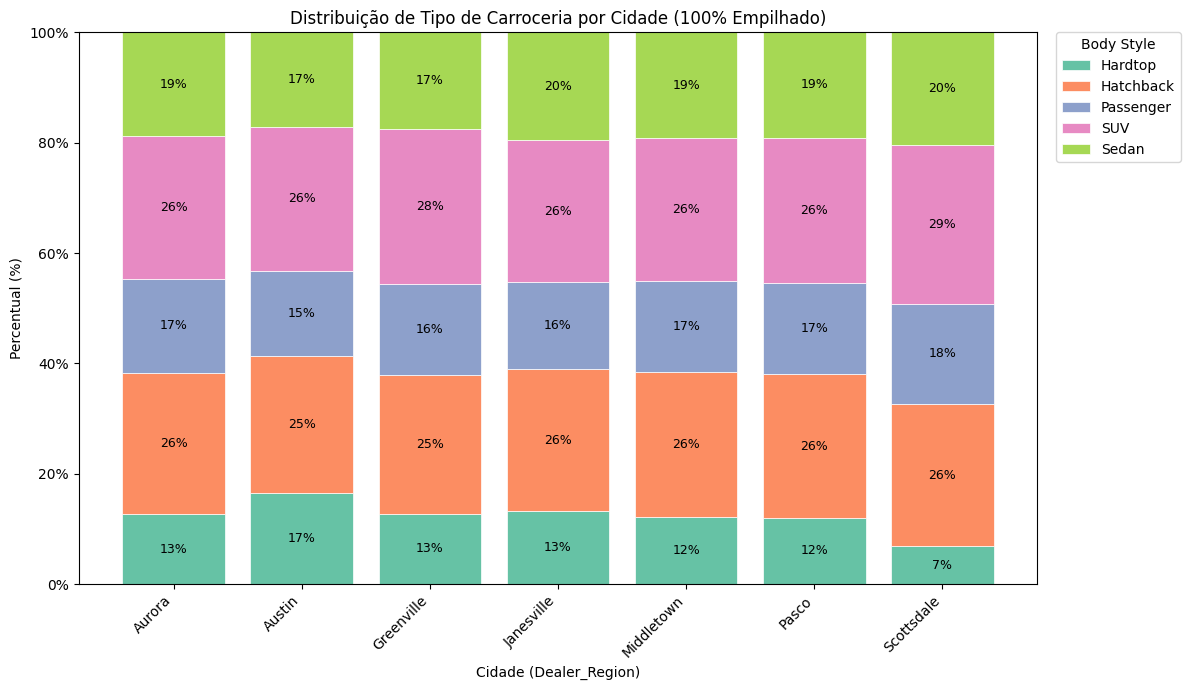

In [ ]:
# Hipótese 1: Para cada cidade existe uma preferência do tipo de carroceria do automóvel?


# 1) Contagem por cidade x Body Style
body_style_by_city = df.groupby(['Dealer_Region', 'Body Style']).size().unstack(fill_value=0)

# 2) Converter para percentuais por linha (cada cidade soma 100%)
row_sums = body_style_by_city.sum(axis=1).replace(0, pd.NA)
body_style_pct = (body_style_by_city.div(row_sums, axis=0) * 100).fillna(0)

# 3) Plot 100% empilhado
fig, ax = plt.subplots(figsize=(12, 7))
bottom = pd.Series(0, index=body_style_pct.index, dtype=float)

colors = plt.cm.Set2.colors
for i, col in enumerate(body_style_pct.columns):
    ax.bar(
        body_style_pct.index,
        body_style_pct[col],
        bottom=bottom,
        label=col,
        color=colors[i % len(colors)],
        edgecolor='white',
        linewidth=0.5
    )
    bottom += body_style_pct[col]

# 4) Adicionar rótulos de porcentagem em cada segmento (oculta segmentos muito pequenos)
for xi, city in enumerate(body_style_pct.index):
    cumulative = 0.0
    for col in body_style_pct.columns:
        val = body_style_pct.loc[city, col]
        if val > 0:
            y_center = cumulative + val / 2
            # Exibir rótulo apenas se o segmento for maior que 3%
            if val >= 3:
                ax.text(
                    xi, y_center,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=9, color='black'
                )
            cumulative += val

# 5) Formatação dos eixos e legendas
ax.set_title('Distribuição de Tipo de Carroceria por Cidade (100% Empilhado)')
ax.set_xlabel('Cidade (Dealer_Region)')
ax.set_ylabel('Percentual (%)')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
plt.xticks(rotation=45, ha='right')
ax.legend(title='Body Style', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

## Hipótese 2

Correlação entre Renda Anual e Preço do Automóvel: 0.01


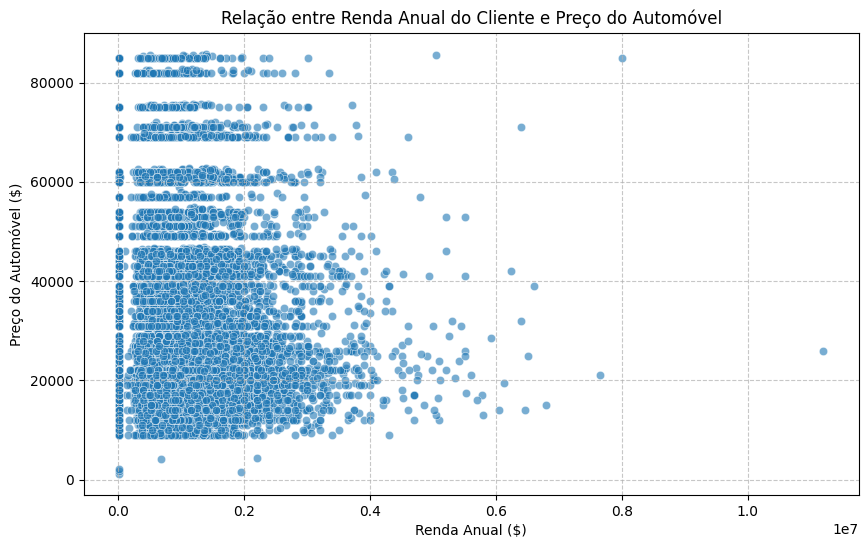

In [ ]:
# Hipótese 2: Existe uma correlação entre renda anual do cliente e preço do automóvel?

# Calcular a correlação entre 'Annual Income' e 'Price ($)'
correlation = df['Annual Income'].corr(df['Price ($)'])
print(f"Correlação entre Renda Anual e Preço do Automóvel: {correlation:.2f}")

# Visualizar a correlação com um scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income', y='Price ($)', data=df, alpha=0.6)
plt.title('Relação entre Renda Anual do Cliente e Preço do Automóvel')
plt.xlabel('Renda Anual ($)')
plt.ylabel('Preço do Automóvel ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Hipótese 3

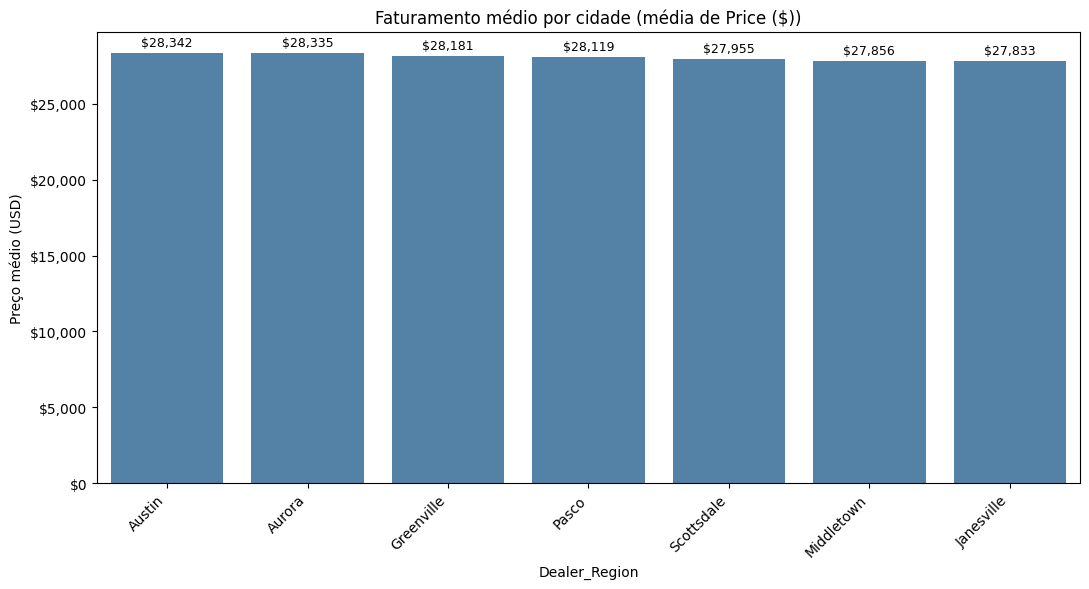

In [ ]:
# Hipótese 3: Qual o faturamento médio por cidade?

# 1) Preparação
df_plot = df.copy()
df_plot['Price ($)'] = pd.to_numeric(df_plot['Price ($)'], errors='coerce')
df_plot = df_plot.dropna(subset=['Dealer_Region', 'Price ($)'])

# 2) Cálculo do faturamento médio por cidade (média do preço)
avg_price_by_city = (
    df_plot.groupby('Dealer_Region', as_index=False)['Price ($)']
           .mean()
           .rename(columns={'Price ($)': 'avg_price'})
           .sort_values('avg_price', ascending=False)
)

# 3) Plot: eixo X = Dealer_Region, eixo Y = média de Price ($) + rótulos no topo
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=avg_price_by_city, x='Dealer_Region', y='avg_price', color='steelblue')

plt.title('Faturamento médio por cidade (média de Price ($))')
plt.xlabel('Dealer_Region')
plt.ylabel('Preço médio (USD)')

# Formatação do eixo Y
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Adicionar rótulos no topo das barras, formatados em USD
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'${height:,.0f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=9, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Hipótese 4

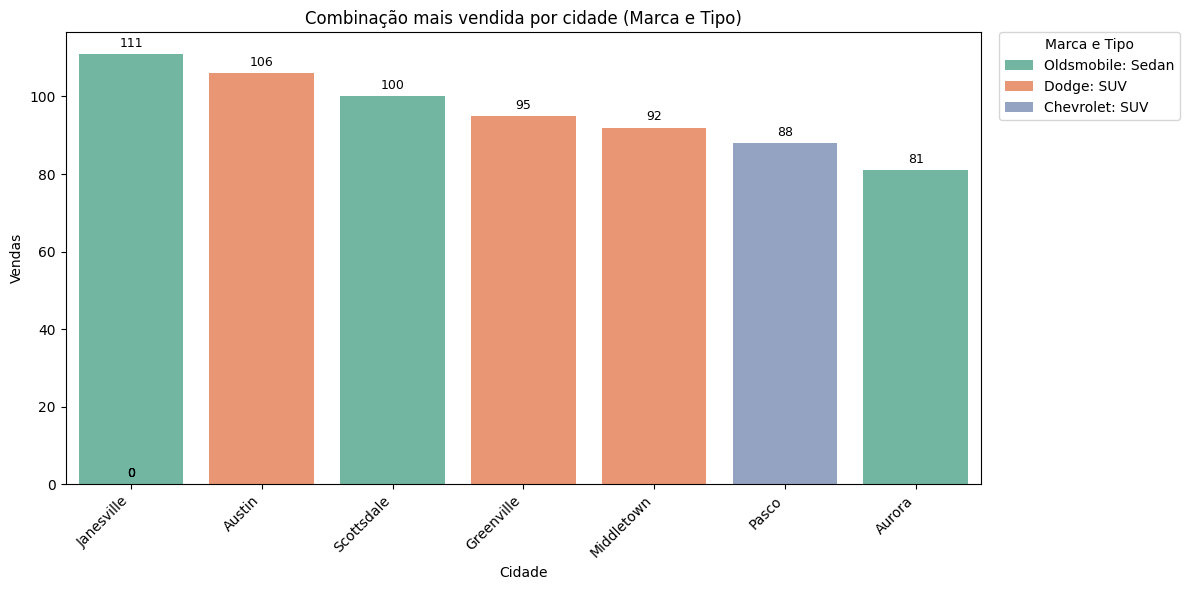

In [ ]:
#Hipótese 4: Qual a marca e tipo de carroceria mais vendida por cidade?


# 1) Preparação
df_plot = df.copy()
df_plot = df_plot.dropna(subset=['Dealer_Region', 'Company', 'Body Style', 'Car_id'])

# Criar a combinação "Company: Body Style"
df_plot['Company_BodyStyle'] = df_plot['Company'].astype(str) + ': ' + df_plot['Body Style'].astype(str)

# 2) Contagem de Car_id por cidade e combinação
counts = (
    df_plot.groupby(['Dealer_Region', 'Company_BodyStyle'])['Car_id']
           .nunique()
           .reset_index(name='sales_count')
)

# 3) Selecionar a combinação mais vendida por cidade
top_combo_by_city = (
    counts.sort_values(['Dealer_Region', 'sales_count'], ascending=[True, False])
          .groupby('Dealer_Region', as_index=False)
          .first()
)

# 4) Ordenar para visualização (da cidade com maior contagem para menor)
top_combo_by_city = top_combo_by_city.sort_values('sales_count', ascending=False)

# 5) Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_combo_by_city,
    x='Dealer_Region',
    y='sales_count',
    hue='Company_BodyStyle',
    dodge=False,
    palette='Set2'
)

plt.title('Combinação mais vendida por cidade (Marca e Tipo)')
plt.xlabel('Cidade')
plt.ylabel('Vendas')

# Legenda no formato "Company: Body Style"
legend = ax.legend(
    title="Marca e Tipo",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.
)

# Rótulos no topo das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points'
    )

# Formatação eixos
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Hipótese 5

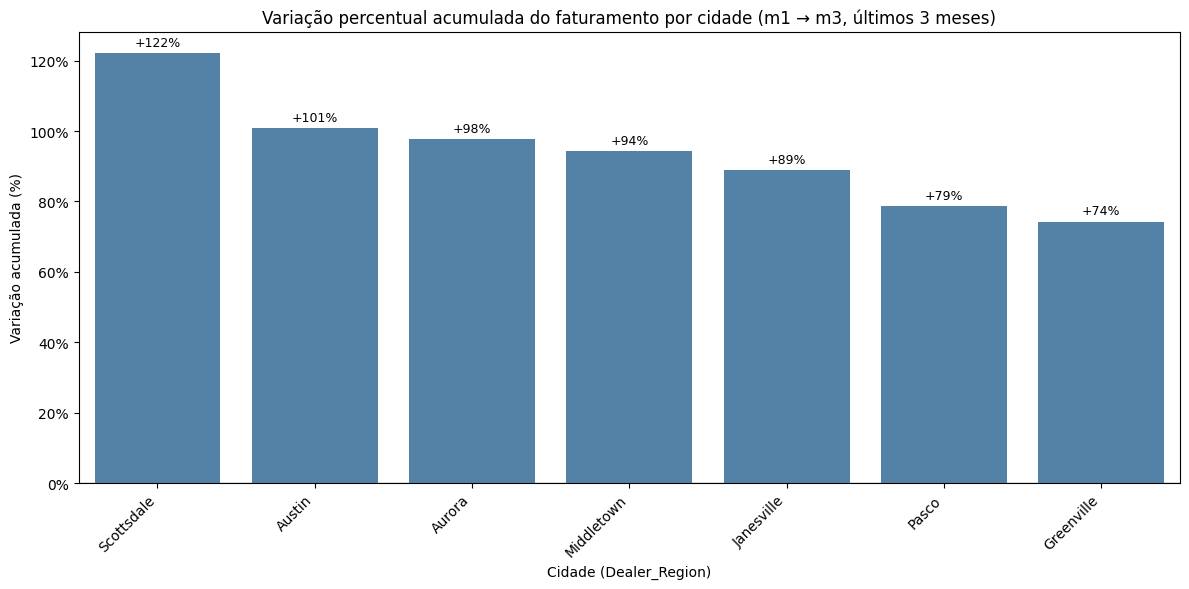

In [ ]:
#Hipótese 5: Qual cidade apresentou o maior crescimento percentual nos últimos 3 meses do período presente no dataset?


# 1) Preparação
df_plot = df.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'], errors='coerce')
df_plot['Price ($)'] = pd.to_numeric(df_plot['Price ($)'], errors='coerce')
df_plot = df_plot.dropna(subset=['Date', 'Price ($)', 'Dealer_Region'])

# 2) Faturamento mensal por cidade
df_plot['YearMonth'] = df_plot['Date'].dt.to_period('M').dt.to_timestamp()
monthly_rev = (
    df_plot.groupby(['Dealer_Region', 'YearMonth'], as_index=False)['Price ($)']
          .sum()
          .rename(columns={'Price ($)': 'revenue'})
)

# 3) Selecionar os últimos 3 meses disponíveis
last_3_months = monthly_rev['YearMonth'].drop_duplicates().sort_values().tail(3).tolist()
monthly_last3 = monthly_rev[monthly_rev['YearMonth'].isin(last_3_months)].copy()

# 4) Calcular a variação percentual acumulada m1 -> m3 para cada cidade:
#    var_acum = (revenue_m3 / revenue_m1 - 1) * 100
#    Observação: se faltar m1 ou m3 para alguma cidade, será removida.
pivot = (
    monthly_last3.pivot_table(
        index='Dealer_Region',
        columns='YearMonth',
        values='revenue',
        aggfunc='sum'
    )
)

# garantir que as colunas estejam na ordem cronológica dos 3 meses
pivot = pivot.reindex(columns=sorted(pivot.columns))

# nomes auxiliares
if len(pivot.columns) == 3:
    m1, m2, m3 = pivot.columns
else:
    # Caso o dataset não tenha exatamente 3 colunas após o filtro
    m1, m3 = pivot.columns.min(), pivot.columns.max()

# calcular variação acumulada m1 -> m3
var_acum = ((pivot[m3] / pivot[m1]) - 1) * 100
bars_df = var_acum.dropna().reset_index()
bars_df.columns = ['Dealer_Region', 'pct_change_acum']

# 5) Gráfico de barras: eixo X = Dealer_Region, Y = variação percentual acumulada (m1→m3)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=bars_df.sort_values('pct_change_acum', ascending=False),
                 x='Dealer_Region', y='pct_change_acum', color='steelblue')

plt.title('Variação percentual acumulada do faturamento por cidade (m1 → m3, últimos 3 meses)')
plt.xlabel('Cidade (Dealer_Region)')
plt.ylabel('Variação acumulada (%)')

# Linha zero para referência
plt.axhline(0, color='gray', linewidth=1)

# Formatação percentual no eixo Y
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))

# Rótulos no topo das barras com sinal
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:+.0f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=9, color='black',
        xytext=(0, 3), textcoords='offset points'
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Conclusão

A análise exploratória mostrou o comportamento das vendas, revelando um equilíbrio no faturamento entre as cidades, assim como entre os tipos de carros vendidos. Não há uma hegemonia de marca, tipo ou de cidade em relação ao faturamento. Além disso, a análise de correlação mostrou que uma renda mais alta não necessariamente reflete a compra de carros mais caros. Já na etapa de tratamento de valores nulos, optei pelo preenchimento com o valor da moda, para minimizar efeitos de outliers. Na etapa de pré-processamento, foi feito um agrupamento de faturamento por cidade e mês/ano e definido um target 'revenue' e foi utilizado uma feature temporal para ajudar o modelo a entender sazonalidade. Por fim, foram aplicadas as técnicas de normalização (MinMaxScaler) e padronização (StandardScaler).  

As cinco hipóteses levantadas foram validadas:

1. **Para cada cidade existe uma preferência do tipo de carroceria do automóvel?**

Sim. Conforme foi observado nos gráficos, os automóveis do tipo SUV e Hatchback são os mais vendidos, com ligeira preferência para o SUV. Porém, em termos de preço médio de venda são os mais baratos. Isso indica que o faturamento com esses veículos são oriundos majoritariamente do volume de venda e não do preço.  

2. **Existe uma correlação entre renda anual do cliente e preço do automóvel?**

Segundo a matriz de correlação o resultado mostra que não há evidência de que clientes com renda maior comprem automóveis mais caros ou mais baratos de forma consistente.
Usando o método Pearson, correlação de 0.012, e o método Spearman, 0.016.
Quando plotado no gráfico que analisa preço do automóvel e renda anual do cliente o resultado mostra que o aumento de renda não se converte na compra de carros mais caros. O gráfico mostra que mesmo veículos mais caros na casa de USD 80k são adquiridos por clientes de faixa de renda inicial de até USD 2,000,000.00

3. **Qual o faturamento médio por cidade?**


A partir da análise foi identificado que a cidade Austin tem o maior faturamento médio $ 28,342. De modo geral, não há disparidade entre as cidades, pelo contrário, existe um faturamento médio bastante equilibrado.

4. **Qual a marca e tipo mais vendida por cidade?**


De acordo com as análises o tipo SUV das marcas Dodge e Chevrolet são os mais vendidos em 4 cidades. Já o tipo Sedan da marca Oldsmobile é o mais vendido em 3 cidades. Nenhum hatchback aparece como o mais vendido em nenhuma cidade apesar de ser o segundo tipo mais vendido no total geral, o que mostra uma diversificação de marcas que oferecem esse tipo de carro.

5. **Qual cidade apresentou o maior crescimento percentual nos últimos 3 meses do período presente no dataset?**


Tendo em vista que é um projeto preditivo sobre o faturamento dos próximos meses, apliquei uma análise sobre o comportamento do faturamento destas cidades nos últimos 3 meses. Importante entender o movimento passado para projetar o futuro. Desta forma, Scottsdale apresentou o maior crescimento 122%, seguido por Austin 101% e Aurora 98%.

